In [18]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

In [20]:
loan_df = pd.read_csv('/Users/ankushkumar/AI-Ml/Ai-Ml-Lab/loan_approval.csv')
loan_df.head()


,applicant_id,age,employment_type,city_tier,annual_income,loan_amount_lakh,credit_score,existing_loans,years_at_job,approved
0,APP1001,58,Salaried,Tier-2,736000,24.2,718.0,0,25.0,1
1,APP1002,46,Salaried,Tier-2,282000,5.6,712.0,4,6.0,0
2,APP1003,48,Salaried,Tier-2,931000,15.5,513.0,2,NaN,0
3,APP1004,56,Salaried,Tier-1,1300000,34.1,682.0,1,16.0,1
4,APP1005,44,Salaried,Tier-1,533000,7.5,742.0,0,12.0,1


In [21]:
loan_df = loan_df.drop(columns=['applicant_id'])
loan_df['credit_score'] = loan_df['credit_score'].fillna(loan_df['credit_score'].median())
loan_df['years_at_job'] = loan_df['years_at_job'].fillna(loan_df['years_at_job'].median())

In [22]:
loan_X = loan_df.drop(columns=['approved'])
loan_y = loan_df['approved']

In [23]:
loan_cat_cols = ['employment_type', 'city_tier']
loan_num_cols = ['age', 'annual_income', 'loan_amount_lakh', 'credit_score', 'existing_loans', 'years_at_job']

In [24]:
loan_X_train, loan_X_test, loan_y_train, loan_y_test = train_test_split(
    loan_X, loan_y, test_size=0.2, random_state=42
)

In [25]:
loan_ct = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), loan_cat_cols),
    ('num', StandardScaler(), loan_num_cols)
])

In [26]:
loan_X_train_t = loan_ct.fit_transform(loan_X_train)
loan_X_test_t = loan_ct.transform(loan_X_test)

In [27]:
loan_knn = KNeighborsClassifier(n_neighbors=5)
loan_knn.fit(loan_X_train_t, loan_y_train)
loan_baseline_acc = accuracy_score(loan_y_test, loan_knn.predict(loan_X_test_t))
print('Loan Approval baseline accuracy (k=5, scaled):', loan_baseline_acc)

Loan Approval baseline accuracy (k=5, scaled): 0.8


Loan Approval accuracy without scaling (k=5): 0.5


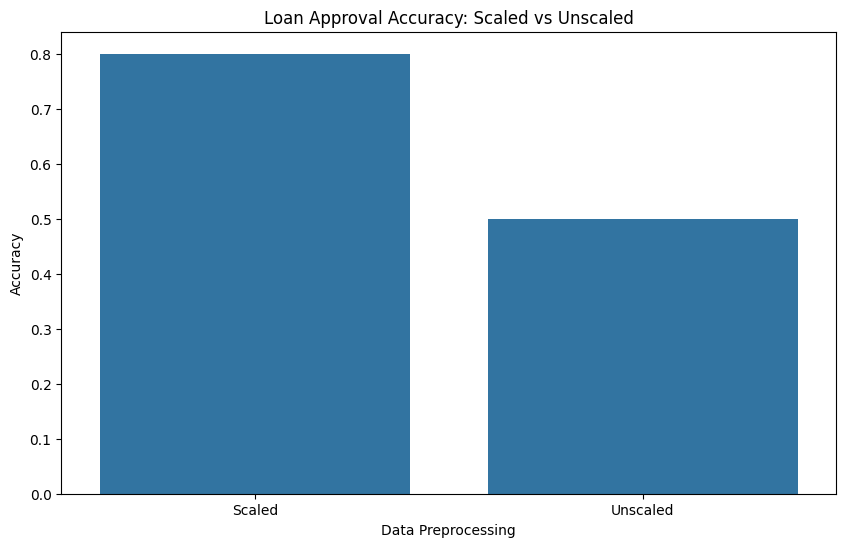

In [28]:
# the main part of ai-ml-lab that is done in class


# Q1.1 — Scaling OFF
# Concept: KNN decides its prediction using distance between points. What happens to that distance if the numeric columns are not scaled?

# Your task:

# Build a new ColumnTransformer called loan_ct_nosc — keep the same OneHotEncoder step for loan_cat_cols, but use the string "passthrough" instead of StandardScaler() for loan_num_cols.
# fit_transform it on loan_X_train, and transform on loan_X_test.
# Train a new KNeighborsClassifier(n_neighbors=5) on this unscaled data.
# Print its accuracy with accuracy_score, next to loan_baseline_acc for comparison.
# Observe: Accuracy should drop. In a comment, write one line answering: why can a large-scale column affect KNN?


loan_ct_nosc = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), loan_cat_cols),
    ('num', 'passthrough', loan_num_cols)
])  

loan_X_train_t_nosc = loan_ct_nosc.fit_transform(loan_X_train)
loan_X_test_t_nosc = loan_ct_nosc.transform(loan_X_test)

loan_knn_nosc = KNeighborsClassifier(n_neighbors=5)
loan_knn_nosc.fit(loan_X_train_t_nosc, loan_y_train)
loan_nosc_acc = accuracy_score(loan_y_test, loan_knn_nosc.predict(loan_X_test_t_nosc))
print('Loan Approval accuracy without scaling (k=5):', loan_nosc_acc)


plt.figure(figsize=(10, 6))
sns.barplot(x=['Scaled', 'Unscaled'], y=[loan_baseline_acc, loan_nosc_acc])
plt.title('Loan Approval Accuracy: Scaled vs Unscaled')
plt.xlabel('Data Preprocessing')
plt.ylabel('Accuracy')
plt.show()


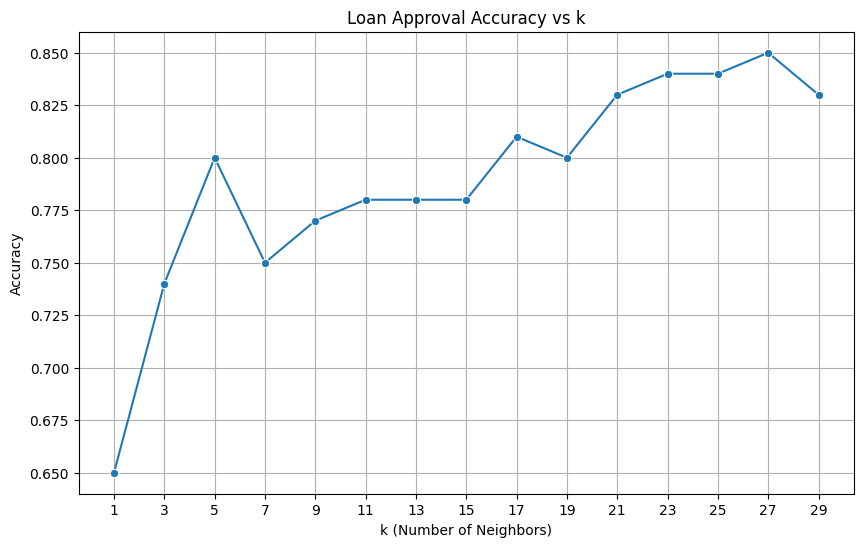

In [29]:
# Q1.2 — Try Different k
# Concept: k is just a setting (hyperparameter) we chose — we assumed k = 5 without checking if it's actually the best choice.

# Your task: Using the already-scaled loan_X_train_t / loan_X_test_t from Setup, write a loop that:

# Starts an empty list called loan_accuracies.
# Loops k over range(1, 30, 2) (every odd number).
# Inside the loop: creates a KNeighborsClassifier(n_neighbors=k), fits it on loan_X_train_t / loan_y_train, and appends its accuracy on the test set to loan_accuracies.
# Run the provided cell below yours to see the accuracy-vs-k graph and the best k.


loan_accuracies = []
for k in range(1, 30, 2):
    loan_knn_k = KNeighborsClassifier(n_neighbors=k)
    loan_knn_k.fit(loan_X_train_t, loan_y_train)
    acc = accuracy_score(loan_y_test, loan_knn_k.predict(loan_X_test_t))
    loan_accuracies.append(acc) 


plt.figure(figsize=(10, 6))
sns.lineplot(x=list(range(1, 30, 2)), y=loan_accuracies, marker='o')
plt.title('Loan Approval Accuracy vs k')
plt.xlabel('k (Number of Neighbors)')
plt.ylabel('Accuracy')
plt.xticks(list(range(1, 30, 2)))
plt.grid()
plt.show()

In [30]:
# Q1.3 — Pipeline
# Concept: A Pipeline combines preprocessing and the model into one object, so you don't have to transform your data and fit your model as two separate steps every time.

# Your task: You already have a working, scaled preprocessor — loan_ct from Setup. Reuse it directly, you do not need to rebuild it.

# Build a Pipeline named pipe with two steps: 'preprocess' → loan_ct, and 'knn' → KNeighborsClassifier(n_neighbors=best_k).
# Fit pipe on loan_X_train and loan_y_train directly (raw, untransformed data — the Pipeline handles the transforming for you).
# Print its accuracy on loan_X_test / loan_y_test, and confirm it matches your best accuracy from Q1.2.



loan_best_k = list(range(1, 30, 2))[np.argmax(loan_accuracies)]
loan_pipe = Pipeline([
    ('preprocess', loan_ct),
    ('knn', KNeighborsClassifier(n_neighbors=loan_best_k))
])
loan_pipe.fit(loan_X_train, loan_y_train)
loan_pipe_acc = accuracy_score(loan_y_test, loan_pipe.predict(loan_X_test))
print(f'Loan Approval accuracy with Pipeline (k={loan_best_k}):', loan_pipe_acc)    




Loan Approval accuracy with Pipeline (k=27): 0.85


In [31]:

flight_df = pd.read_csv('flight_delay.csv')
print(flight_df.shape)
print(flight_df.isnull().sum())

(400, 9)
flight_id           0
airline             0
weather             0
day_type            0
departure_hour      0
airport_traffic    10
plane_age_years    12
distance_km         0
delayed             0
dtype: int64


In [32]:
loan_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               500 non-null    int64  
 1   employment_type   500 non-null    str    
 2   city_tier         500 non-null    str    
 3   annual_income     500 non-null    int64  
 4   loan_amount_lakh  500 non-null    float64
 5   credit_score      500 non-null    float64
 6   existing_loans    500 non-null    int64  
 7   years_at_job      500 non-null    float64
 8   approved          500 non-null    int64  
dtypes: float64(3), int64(4), str(2)
memory usage: 42.8 KB


In [33]:
# Q2.1 — Clean the Data
loan_df = flight_df.drop(columns=['flight_id'])
print(loan_df.shape)
print(loan_df.isnull().sum())



(400, 8)
airline             0
weather             0
day_type            0
departure_hour      0
airport_traffic    10
plane_age_years    12
distance_km         0
delayed             0
dtype: int64
